In [1]:

import torch
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
from data.dataset import Conll2003Dataset
from data.dataloader import get_dataloader
from models.model import BiGRUTagger, BiLSTMTagger, BiRNNTagger
from utils.visualization import plot_training_summary
from models.vocab import Vocab
from scripts.eval import collect_predictions
from scripts.train import train
from scripts.main import load_config

In [2]:

config = load_config("../config/config.yaml")

model_cfg = config["model"]
train_cfg = config["training"]
data_cfg = config["data"]

ds_train = Conll2003Dataset(data_cfg["train_split"])
ds_val = Conll2003Dataset(data_cfg["val_split"])

vocab = Vocab(ds_train, tag_key=train_cfg["tag_key"])
train_dl = get_dataloader(ds_train, batch_size=train_cfg["batch_size"])
val_dl = get_dataloader(ds_val, batch_size=train_cfg["batch_size"])

device = torch.device("cpu")


In [3]:

def get_model_and_optimizer(model_class):
    model = model_class(
        vocab_size=len(vocab),
        num_classes=vocab.num_tags(),
        embed_dim=model_cfg["embed_dim"],
        hidden_dim=model_cfg["hidden_dim"],
        num_layers=model_cfg["num_layers"],
        dropout=model_cfg["dropout"],
        pad_idx=vocab.token_to_id("<pad>"),
    ).to(device)

    optimizer   = torch.optim.Adam(model.parameters(), lr=train_cfg["lr"])
    return model, optimizer


In [4]:
cache = {}
def proccess_model(model_class):
    if val := cache.get(model_class.__name__):
        return val

    model, optimizer = get_model_and_optimizer(model_class)
    metadata = train(
        model,
        train_dl,
        val_dl,
        vocab,
        optimizer,
        device,
        epochs=train_cfg["epochs"],
        tag_key=train_cfg["tag_key"],
        verbose=train_cfg.get("verbose", True),
    )
    y_true, y_pred = collect_predictions(
        model, val_dl, vocab, device, tag_key=config["training"]["tag_key"]
    )
    target_names = [vocab.id_to_tag(i) for i in range(vocab.num_tags())]
    report = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        digits=4,
        output_dict=True,
    )
    ans = (metadata, report)
    cache[model_class.__name__] = ans
    return ans

Duration=23.67s
Duration=51.27s
Duration=43.49s


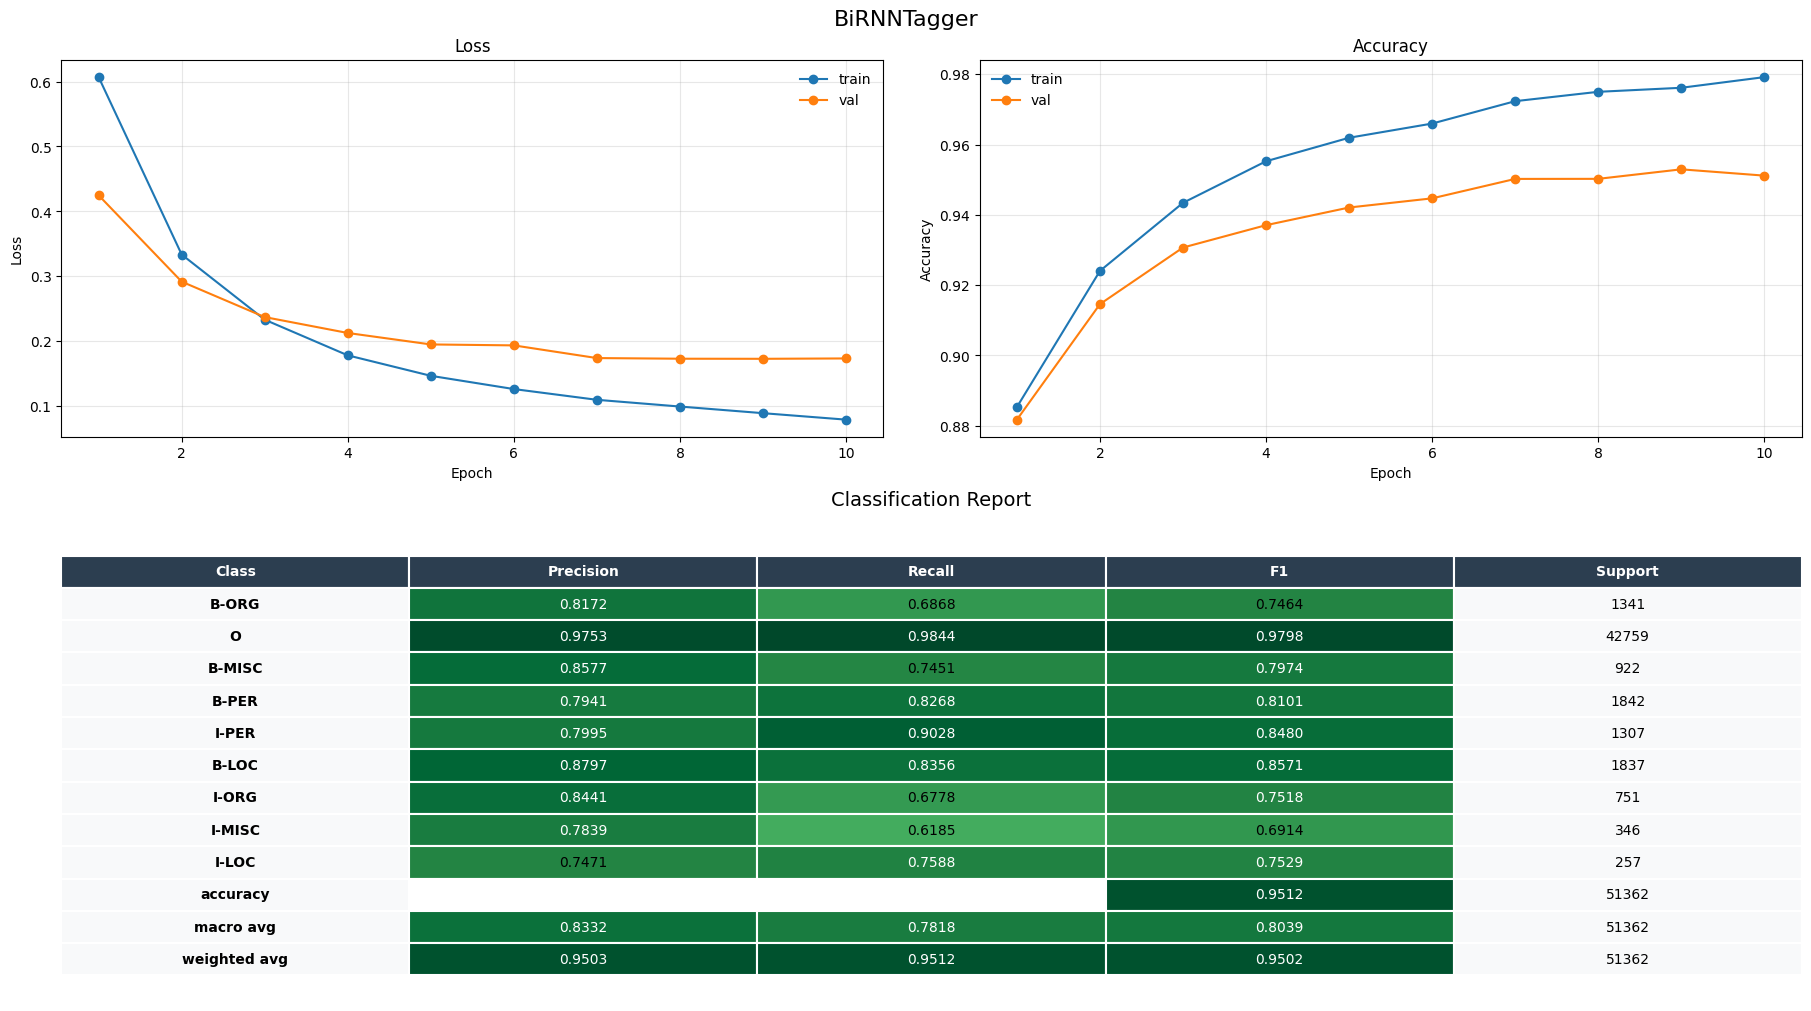

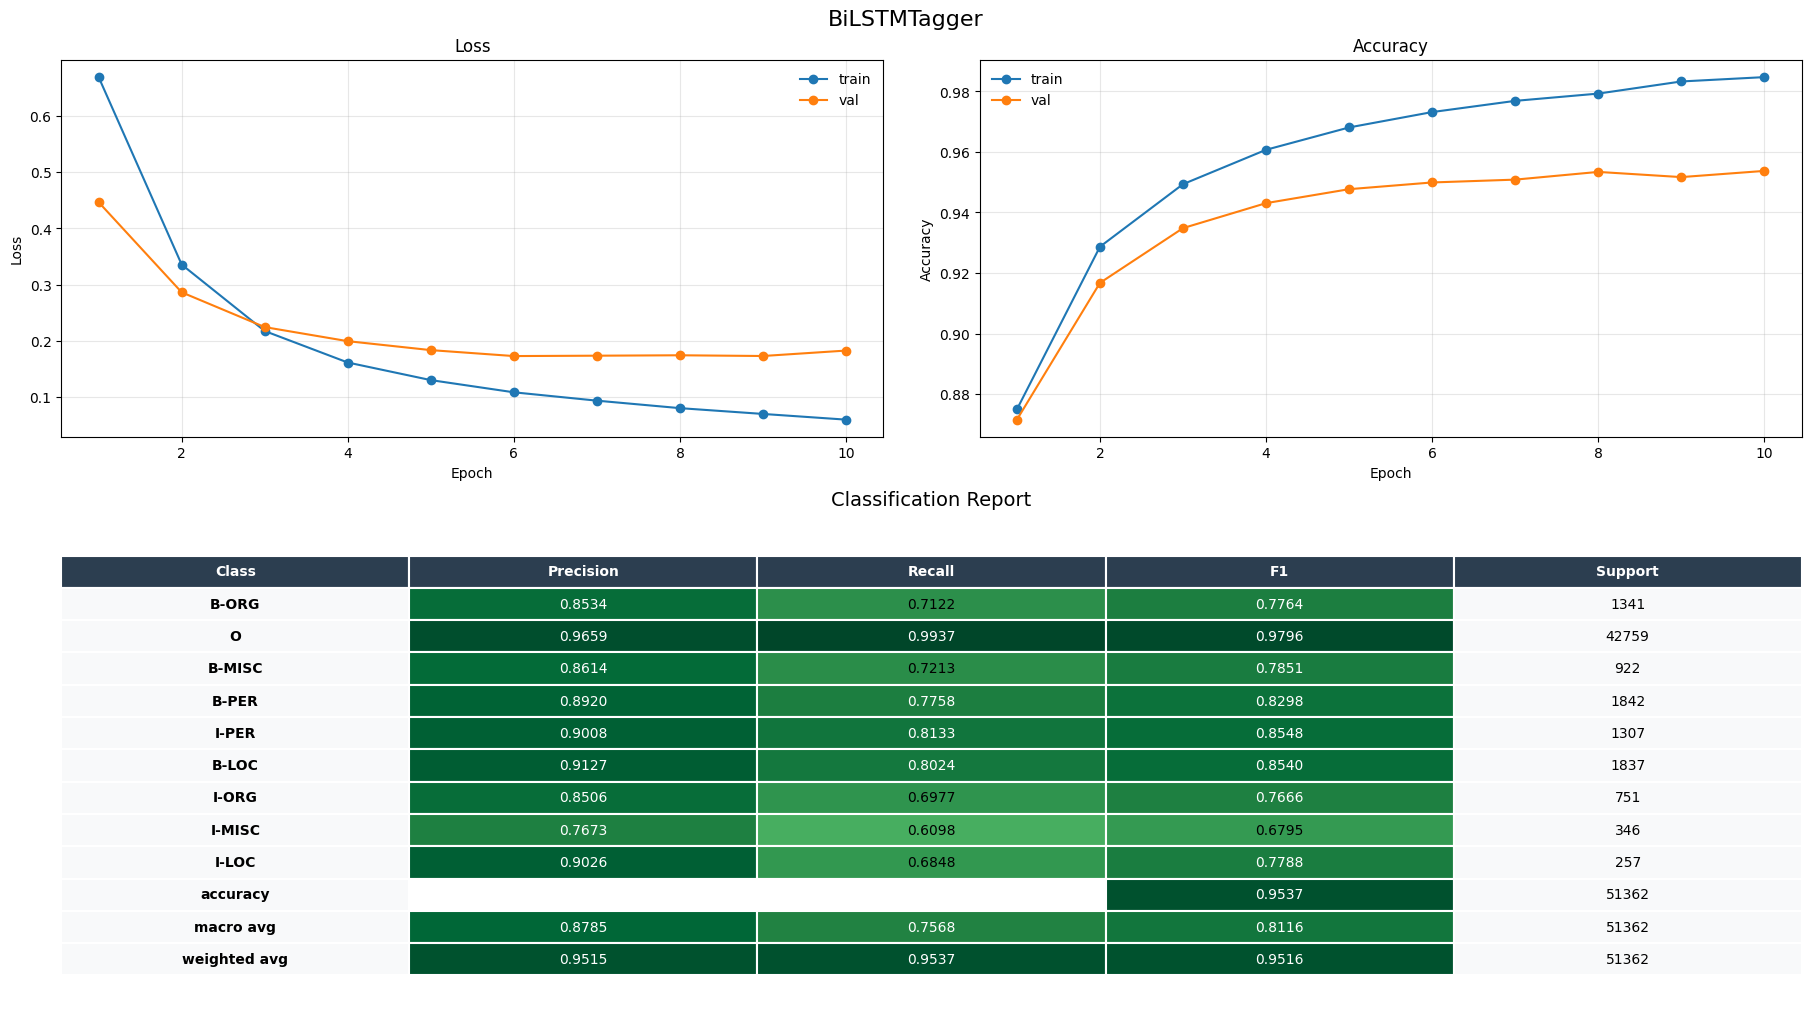

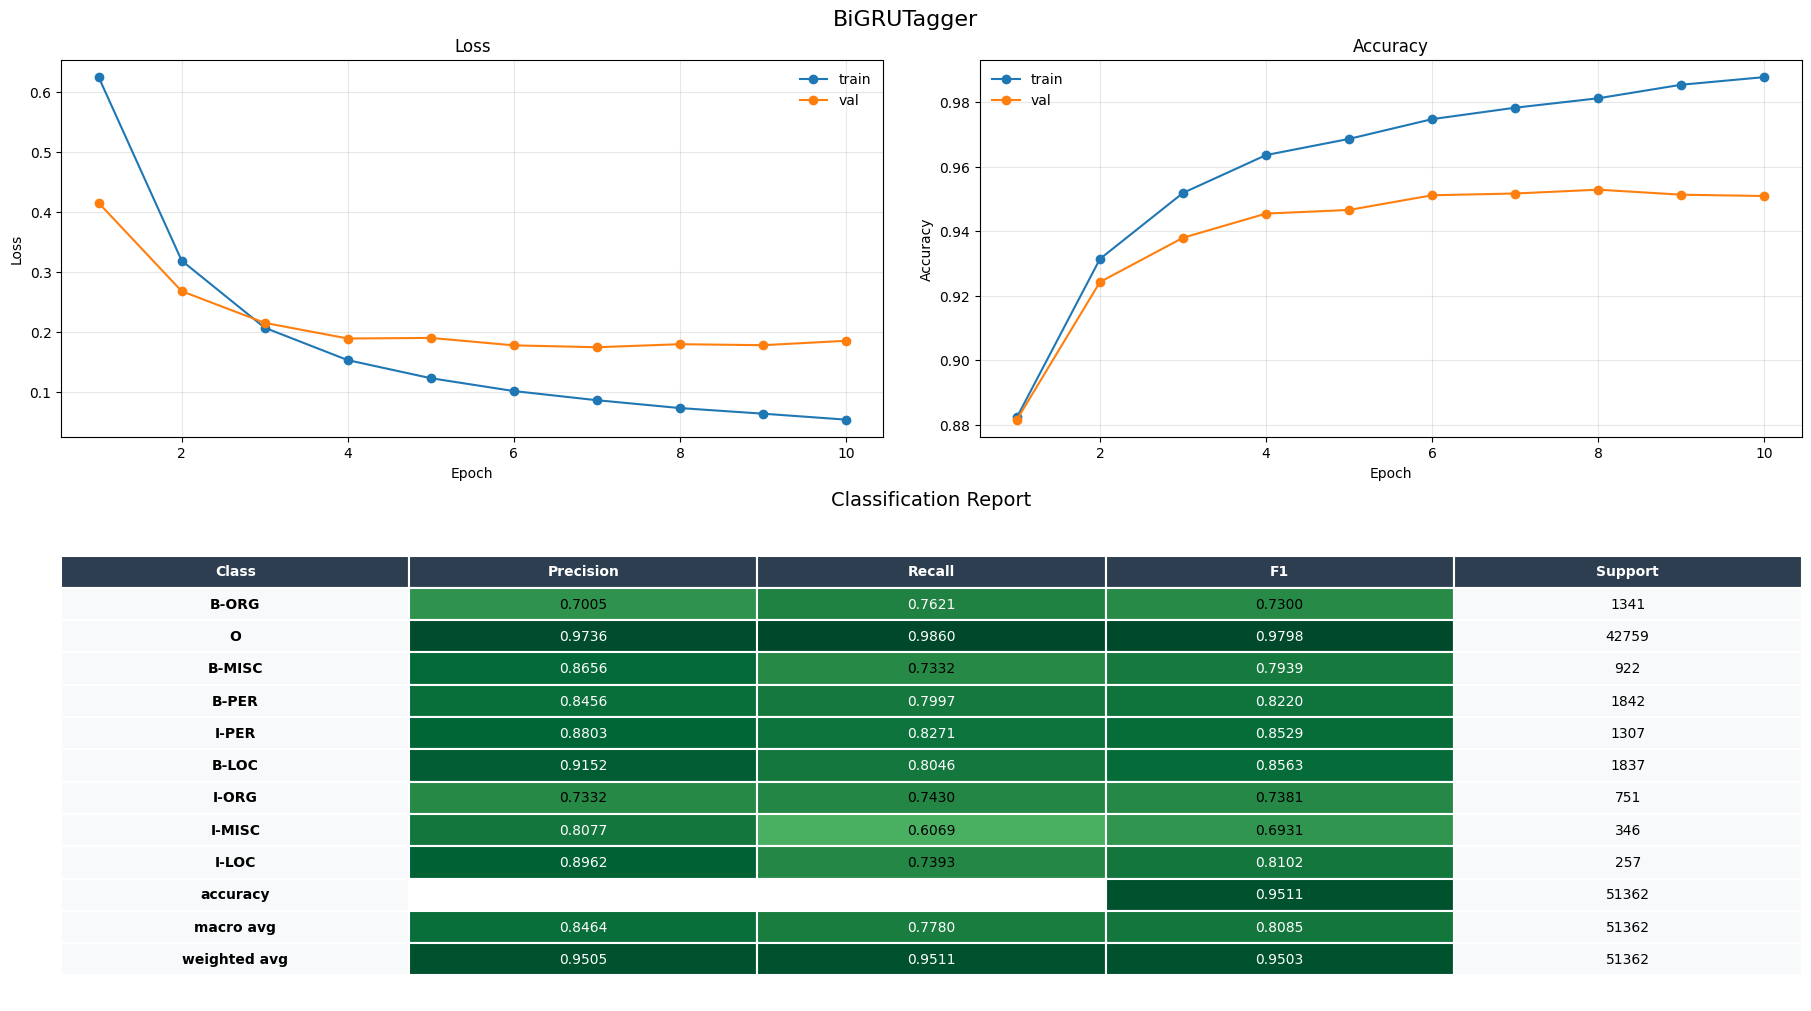

In [5]:
model_data = {}
for model_class in (
    BiRNNTagger,
    BiLSTMTagger,
    BiGRUTagger
):
    train_metadata, class_report = proccess_model(model_class)
    model_data[model_class.__name__] = train_metadata

    plot_training_summary(train_metadata, class_report, model_name=model_class.__name__)
    plt.savefig(f"../../report/images/q1-{model_class.__name__}.png", bbox_inches="tight")

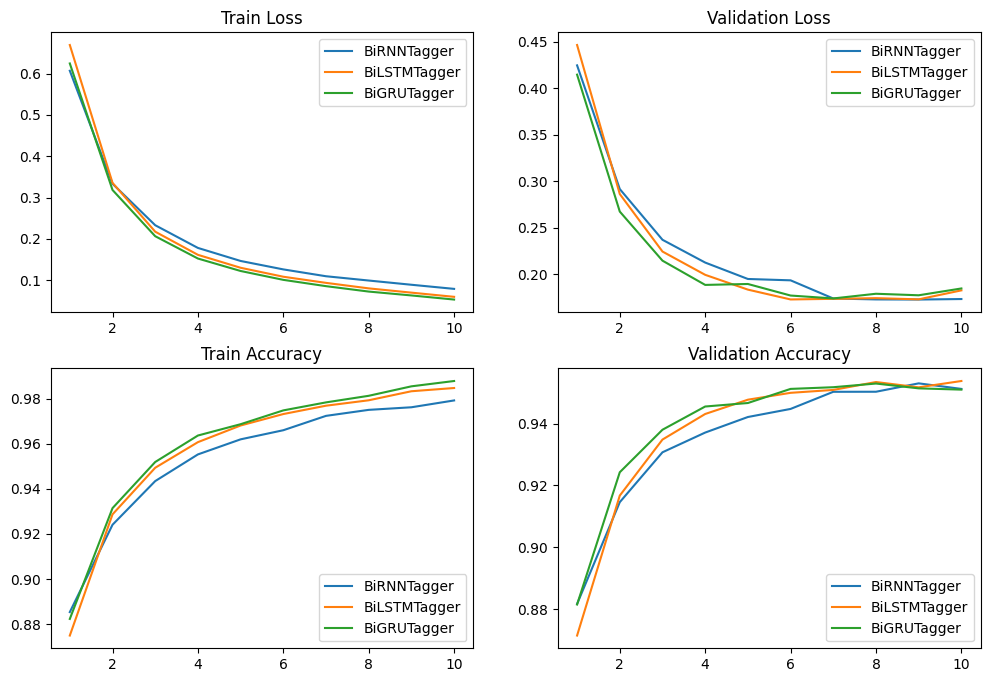

In [6]:
plt.figure(figsize=(12, 8))
for model_class in (
    BiRNNTagger,
    BiLSTMTagger,
    BiGRUTagger
):
    train_metadata = model_data[model_class.__name__]
    plt.subplot(2, 2, 1)
    x = range(1, train_cfg["epochs"] + 1)
    plt.plot(
        x,
        [i["train_loss"] for i in train_metadata],
        label=model_class.__name__,
    )
    plt.subplot(2, 2, 2)
    plt.plot(
        x,
        [i["val_loss"] for i in train_metadata],
        label=model_class.__name__,
    )
    plt.subplot(2, 2, 3)
    plt.plot(
        x,
        [i["train_acc"] for i in train_metadata],
        label=model_class.__name__,
    )
    plt.subplot(2, 2, 4)
    plt.plot(
        x,
        [i["val_acc"] for i in train_metadata],
        label=model_class.__name__,
    )
plt.subplot(2, 2, 1)
plt.title("Train Loss")
plt.legend()
plt.subplot(2, 2, 2)
plt.title("Validation Loss")
plt.legend()
plt.subplot(2, 2, 3)
plt.title("Train Accuracy")
plt.legend()
plt.subplot(2, 2, 4)
plt.title("Validation Accuracy")
plt.legend()
plt.savefig(f"../../report/images/q1-combined.png", bbox_inches="tight")